# Wetter-Ingestion via Open-Meteo (ERA5)

In [8]:
import json

import matplotlib.pyplot as plt
import pandas as pd
import requests

# Open-Meteo Historical Weather API (ERA5 reanalysis archive)
# Docs: https://open-meteo.com/en/docs/historical-weather-api
BASE_URL = "https://archive-api.open-meteo.com/v1/archive"

# Single representative point: geographic centre of Germany
LATITUDE = 51.2
LONGITUDE = 10.4

HOURLY_VARS = [
    "shortwave_radiation",
    "direct_radiation",
    "diffuse_radiation",
    "temperature_2m",
    "cloud_cover",
    "relative_humidity_2m",
    "wind_speed_10m",
]


def request_data(url: str, params: dict) -> dict:
    """Request data from the Open-Meteo archive and return parsed JSON."""
    response = requests.get(url, params=params, timeout=60)
    response.raise_for_status()
    return response.json()


def build_params(start_date: str, end_date: str) -> dict:
    """Build the archive query: UTC timestamps, ERA5 model, the 7 hourly vars."""
    return {
        "latitude": LATITUDE,
        "longitude": LONGITUDE,
        "start_date": start_date,
        "end_date": end_date,
        "hourly": ",".join(HOURLY_VARS),
        "timezone": "UTC",
        "models": "era5",
    }

In [9]:
mini = request_data(BASE_URL, build_params("2023-06-20", "2023-06-21"))

print("Top-Level-Keys:", list(mini.keys()))
for k in ("latitude", "longitude", "elevation", "timezone", "utc_offset_seconds"):
    print(f"  {k}: {mini[k]}")
print("hourly-Keys:", list(mini["hourly"].keys()))
print("Einheiten:", json.dumps(mini["hourly_units"], ensure_ascii=False))
print("Erste Zeitstempel:", mini["hourly"]["time"][:3])
print("GHI nachts  (idx 0-3) :", mini["hourly"]["shortwave_radiation"][:4])
print("GHI mittags (idx 12-14):", mini["hourly"]["shortwave_radiation"][12:15])

Top-Level-Keys: ['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'hourly_units', 'hourly']
  latitude: 51.25
  longitude: 10.5
  elevation: 287.0
  timezone: GMT
  utc_offset_seconds: 0
hourly-Keys: ['time', 'shortwave_radiation', 'direct_radiation', 'diffuse_radiation', 'temperature_2m', 'cloud_cover', 'relative_humidity_2m', 'wind_speed_10m']
Einheiten: {"time": "iso8601", "shortwave_radiation": "W/m²", "direct_radiation": "W/m²", "diffuse_radiation": "W/m²", "temperature_2m": "°C", "cloud_cover": "%", "relative_humidity_2m": "%", "wind_speed_10m": "km/h"}
Erste Zeitstempel: ['2023-06-20T00:00', '2023-06-20T01:00', '2023-06-20T02:00']
GHI nachts  (idx 0-3) : [0.0, 0.0, 0.0, 0.0]
GHI mittags (idx 12-14): [766.0, 540.0, 575.0]


## Parsing the parallel `hourly` arrays

In [10]:
def parse_hourly(payload: dict) -> pd.DataFrame:
    """Turn the parallel hourly arrays into a tidy DataFrame with a UTC time column."""
    df = pd.DataFrame(payload["hourly"])
    df["time"] = pd.to_datetime(df["time"], utc=True)
    return df


df_mini = parse_hourly(mini)
print("Shape:", df_mini.shape)
print(df_mini.dtypes)
df_mini.head()

Shape: (48, 8)
time                    datetime64[us, UTC]
shortwave_radiation                 float64
direct_radiation                    float64
diffuse_radiation                   float64
temperature_2m                      float64
cloud_cover                           int64
relative_humidity_2m                  int64
wind_speed_10m                      float64
dtype: object


,time,shortwave_radiation,direct_radiation,diffuse_radiation,temperature_2m,cloud_cover,relative_humidity_2m,wind_speed_10m
0,2023-06-20 00:00:00+00:00,0.0,0.0,0.0,19.9,56,78,6.3
1,2023-06-20 01:00:00+00:00,0.0,0.0,0.0,18.6,74,85,5.4
2,2023-06-20 02:00:00+00:00,0.0,0.0,0.0,18.3,97,86,6.2
3,2023-06-20 03:00:00+00:00,0.0,0.0,0.0,18.2,100,87,6.1
4,2023-06-20 04:00:00+00:00,12.0,0.0,12.0,18.2,100,89,5.2


## Retrieval and storage as raw CSV

In [11]:
payload = request_data(BASE_URL, build_params("2014-12-30", "2025-12-31"))
df_raw = parse_hourly(payload)

out_path = "../data/raw/weather_openmeteo_era5_2015-2026.csv"
df_raw.to_csv(out_path, index=False)
print(f"Fertig: {len(df_raw)} Stundenwerte gespeichert unter '{out_path}'")
print(
    "Genutzte Gitterzelle:",
    payload["latitude"],
    payload["longitude"],
    "| Elevation:",
    payload["elevation"],
    "m",
)

Fertig: 96480 Stundenwerte gespeichert unter '../data/raw/weather_openmeteo_era5_2015-2026.csv'
Genutzte Gitterzelle: 51.25 10.5 | Elevation: 287.0 m


## Schritt 4 — Sanity-Checks

In [12]:
# Row count vs. expected hourly grid
expected = pd.date_range("2014-12-30 00:00", "2025-12-31 23:00", freq="h", tz="UTC")
print(f"Zeilen: {len(df_raw)} | erwartetes Stundenraster: {len(expected)}")

w = df_raw.set_index("time")

na = w.isna().sum()
print("\nNaN je Spalte:\n", na)
if na.any():
    bad = w[w.isna().any(axis=1)].index
    print("NaN-Zeitstempel (Ränder?):", bad.min(), "...", bad.max())

# Night-time GHI: expect exactly/near 0
g = w["shortwave_radiation"]
night = g[g.index.hour.isin([23, 0, 1, 2])]
print(
    f"\nNacht-GHI: min={night.min()}, max={night.max()} | "
    f"#negative GHI gesamt={int((g < 0).sum())}"
)

Zeilen: 96480 | erwartetes Stundenraster: 96480

NaN je Spalte:
 shortwave_radiation     0
direct_radiation        0
diffuse_radiation       0
temperature_2m          0
cloud_cover             0
relative_humidity_2m    0
wind_speed_10m          0
dtype: int64

Nacht-GHI: min=0.0, max=0.0 | #negative GHI gesamt=0


In [13]:
# Plausible ranges / units across all variables.
df_raw.describe()

,shortwave_radiation,direct_radiation,diffuse_radiation,temperature_2m,cloud_cover,relative_humidity_2m,wind_speed_10m
count,96480.000000,96480.000000,96480.000000,96480.000000,96480.000000,96480.000000,96480.000000
mean,129.323404,73.979156,55.344248,9.900514,69.065184,76.949575,11.917053
std,200.142985,142.374456,76.487337,7.790407,35.545223,16.511429,6.270771
min,0.000000,0.000000,0.000000,-20.500000,0.000000,9.000000,0.000000
25%,0.000000,0.000000,0.000000,3.900000,41.000000,67.000000,7.200000
50%,5.000000,0.000000,5.000000,9.500000,87.000000,82.000000,10.500000
75%,199.000000,75.000000,99.000000,15.500000,100.000000,90.000000,15.700000
max,908.000000,786.000000,425.000000,38.000000,100.000000,100.000000,51.800000


## GHI daily trend

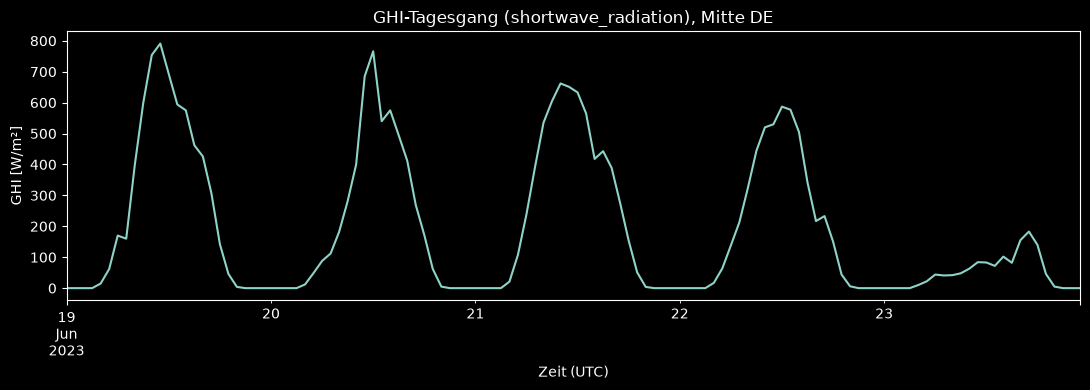

In [14]:
sample = w.loc["2023-06-19":"2023-06-23", "shortwave_radiation"]
ax = sample.plot(figsize=(11, 4), title="GHI-Tagesgang (shortwave_radiation), Mitte DE")
ax.set_ylabel("GHI [W/m²]")
ax.set_xlabel("Zeit (UTC)")
plt.tight_layout()
plt.show()